# Lecture 1 - Monte Carlo methods
A Monte Carlo method is an algorithm that uses random numbers in a calculation that has the structure of a stochastic process, i.e. a sequence of states whose evolution is determined by random events. In a computer simulation these numbers are actually pseudo-random.

## Random numbers and Central Limit Theorem
Given $N$ statistically independent and identically distributed random variables $x_1, \dots, x_N$, we can define the sample average as
$$
A_N = \frac{1}{N} \sum_{n=1}^{N} x_n
$$
The two main ideas behind the Monte Carlo methods  are
1. The law of large numbers $\rightarrow$ as $N$ becomes very large, the sample average $A_N$ converges to the true expected value $\langle x \rangle$.
2. The Central Limit Theorem $\rightarrow$ for large $N$, the distribution of our estimate $A_N$ will be approximately Gaussian, regardless of the underlying distribution of $x$. This allows us to quantify our uncertainty.

Since the variables are independent, their joint probability density function is the product of their individual pdfs: $p_N(x_1, x_2, \dots, x_N) = p(x_1)p(x_2)\cdots p(x_N)$.

The theorem tells us that for $N \to \infty$, the probability density of the average ($P_N(A_N)$) and the sum ($P_N(S_N)$) universally approach a Gaussian distribution
$$
P_N(A_N) \to \frac{1}{\sqrt{2\pi\sigma_{A_N}^2}} \exp \left[ -\frac{(A_N - \mu)^2}{2\sigma_{A_N}^2} \right].
$$

## Data Blocking
The Data Blocking technique is used to estimate the statistical uncertainty of a sample average when the data are correlated. The standard formula for the error of the average reads 
$$
\sigma_{\langle x \rangle} = \frac{\sigma}{\sqrt{M}}
$$
but it is only valid if the $M$ data points are independent and identically distributed. 
In many systems, like in our case, the data points are correlated in time. 
So the idea is to group the data into blocks that are large enough to be considered independent of one another. Then we divide the total set of $M$ data points into $N$ blocks, where each block contains $L = M/N$ elements and we calculate the arithmetic mean for each individual block $j$
$$
\bar{x}_j = \frac{1}{L} \sum_{i=1}^{L} x_{(j-1)L + i}
$$
The global average is then the mean of these block averages
$$
\langle \bar{x} \rangle = \frac{1}{N} \sum_{j=1}^{N} \bar{x}_j
$$
The error on the global mean is calculated as the standard deviation of the mean of these blocks
$$
\sigma_{\langle \bar{x} \rangle} = \sqrt{\frac{1}{N(N-1)} \sum_{j=1}^{N} (\bar{x}_j - \langle \bar{x} \rangle)^2}$$

## $\chi^2$ test
Pearson's cumulative test statistic $\chi^2$ is a measure of the error between observations, $O_i$, and expected values, $E_i$:
$$
\chi^2 = \sum_{i} \frac{\left( O_i - E_i \right)^2}{E_i}
$$
The numerator is a squared distance between observations, $O_i$, and expected values, $E_i$, and thus should be compared (at the denominator) with the expected squared fluctuations (variance) of the relative distribution. Why variance = $E_i$? 
The probability of getting exactly $k$ (independent) successes, each one with probability $p$, in $n$ trials is given by the Binomial distribution (see <a href="https://en.wikipedia.org/wiki/Binomial_distribution">this Wikipedia link</a>):
$$
Pr(X=k) = {{n}\choose{k}} p^k (1-p)^{n-k} = \frac{n!}{k! (n-k)!} p^k (1-p)^{n-k}
$$
The average of the Binomial distribution is $$ \langle X \rangle = np $$, the variance is: $\sigma^2 = np (1-p)$. Thus if $p$ is small we have that $\sigma^2 \simeq np$, that is $\sigma^2 \simeq \langle X \rangle$ and this explains the denominator $E_i$ in $\chi^2$
</p>

## Exercise 1.1
Test the Pseudo-Random Number generator downloaded from the NSL Ariel web site by estimating:

1. $\langle r \rangle = \int_0^1 r dr = 1/2$.  Make a picture of the estimation of $\langle r \rangle$ and its uncertainty (which corresponds to Standard Deviation of the mean for the estimation of $\langle r \rangle$) with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$   (see below: Computing statistical uncertainties).

2. $\sigma^2 = \int_0^1 (r-1/2)^2 dr = 1/12$.  Make a picture of the estimation of $\sigma^2$ and its uncertainty (which corresponds to Standard Deviation of the mean for the estimation of $\langle (r-1/2)^2 \rangle$) with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$   (see below: Computing statistical uncertainties).


The hypothesis is that the numbers $r$ are drawn from a uniform distribution. In Statistics we cannot prove that some random events are drawn from a particular distribution (Note, in fact, that such hypothesis is false: pseudo-random numbers are drawn from a deterministic algorithm!); we can try to estimate the probability that $r$ **are not** drawn from a uniform distribution. If this probability is low, we can safely reject this last hypothesis.

3. Divide $[0,1]$ into $M$ identical sub-intervals and implement the $\chi^2$ test. Obviously, the number of expected events observed in each sub-interval after $n$ *throws*, according to a uniform distribution, is $np = n\times 1/M= n/M$. Fix $M=10^2$ and use for $n$ the first $10^4$ pseudo-random numbers, then the successive $10^4$ pseudo-random numbers, and so on ... 100 times. Plot $\chi^2_j$ for $j=1, ..., 100$. In this case the chi-square statistic is:
$$\chi^2 = \sum_{i=1}^M \frac{\left( n_i - n/M \right)^2}{n/M}$$
We should expect on average that $(n_i - n/M)^2 \simeq n/M$ and thus $\chi^2 \simeq 100$, i.e. the number of sub-intervals.
A larger value of $\chi^2$ indicates that the hypothesis ($n_i$ are drawn from a uniform distribution) is rather unlikely ...  but before judging  , you could compare the histogram of the values obtained for $\chi^2_j$ with the true probability distribution (see: <a href="https://en.wikipedia.org/wiki/Chi-squared_distribution">this Wikipedia link</a>).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from scipy.stats import norm
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

plt.style.use('default')
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

## Exercise 1.1 - Solution 
### Integrals calculation
We employed a Monte Carlo (MC) simulation to numerically estimate the integral $\langle r \rangle = \int_0^1 r \, dr$. Using a pseudorandom number generator sampled from a uniform distribution $[0,1)$, we performed a total of $M = 10^4$ throws.To mitigate potential correlations and provide a robust estimate of statistical uncertainties, we implemented the data blocking method.
The total sample was divided into $N = 100$ blocks, with each block containing $L = 100$ points.

The figures below illustrate the convergence of the progressive averages for both the integral and the variance, which is $\sigma^2 = \int_0^1 (r-1/2)^2 dr = 1/12$. The results are compared against the expected analytical values, with statistical uncertainties plotted as a function of the total number of throws.

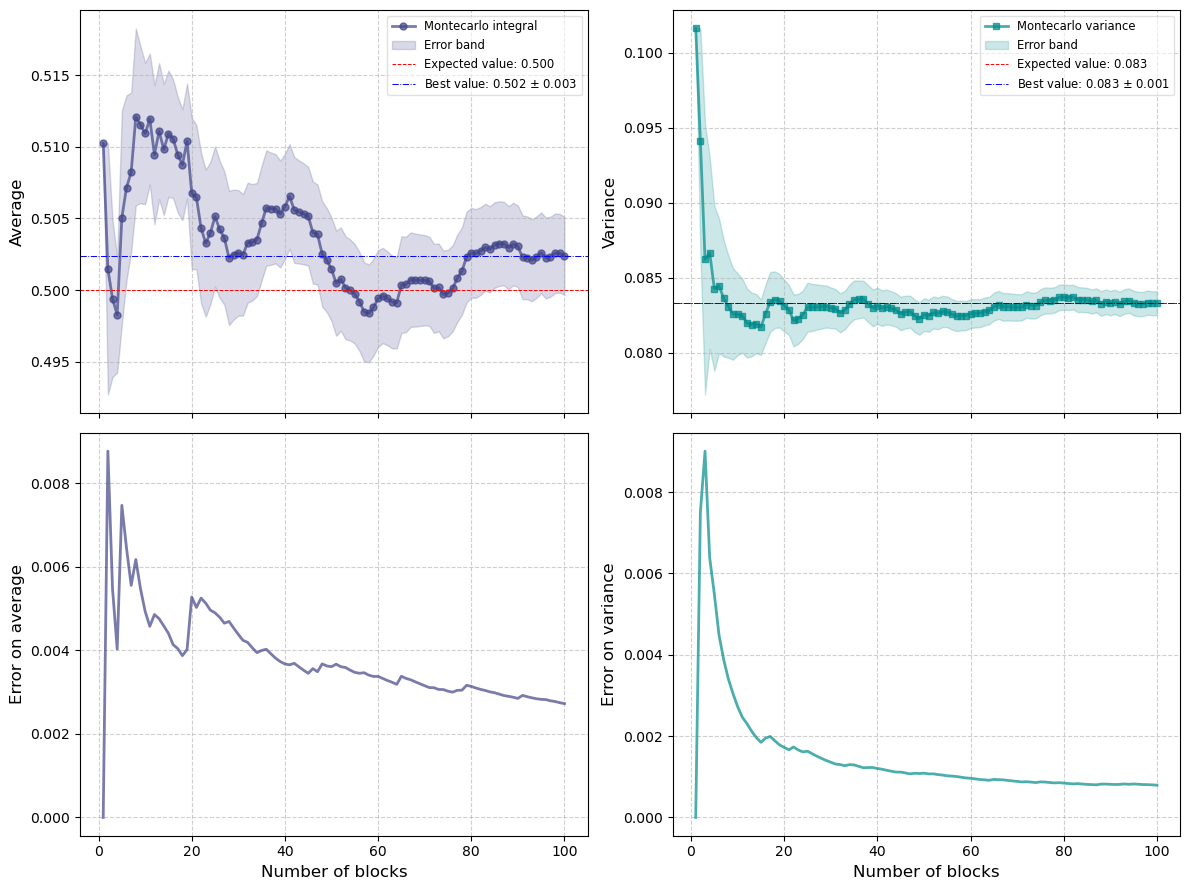

In [3]:
file_avg = "Exercise_1_1/output_average.data"
x1, y1, error1 = np.loadtxt(file_avg, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x3, y3 = np.loadtxt(file_avg, usecols=(0, 2), delimiter='\t', unpack=True)

file_var = "Exercise_1_1/output_variance.data"
x2, y2, error2 = np.loadtxt(file_var, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x4, y4 = np.loadtxt(file_var, usecols=(0, 2), delimiter='\t', unpack=True)

viridis = plt.cm.viridis
color_avg = viridis(0.2)
color_var = 'darkcyan'

fig, axs = plt.subplots(2, 2, figsize=(12, 9))

# Average
axs[0, 0].plot(x1/100, y1, 'o-', color=color_avg, alpha=0.7, markersize=5, label='Montecarlo integral')

axs[0, 0].fill_between(x1/100, y1 - error1, y1 + error1,
                       color=color_avg, alpha=0.2, label='Error band')

axs[0, 0].axhline(y=0.5, color='red', linestyle='--', linewidth=0.7,
                 label=f'Expected value: {1./2.:.3f}')

axs[0, 0].axhline(y=y1[99], color='blue', linestyle='-.', linewidth=0.7,
                 label=rf'Best value: {y1[99]:.3f} $\pm$ {error1[99]:.3f}')
axs[0, 0].set_ylabel('Average')
axs[0, 0].legend(loc='upper right', frameon=True, fancybox=True,
                 facecolor='white', framealpha=0.6, fontsize='small')
axs[0, 0].grid(True, alpha=0.6, linestyle='--')
axs[0, 0].tick_params(axis='x', labelbottom=False)

# Variance
axs[0, 1].plot(x2/100, y2, 's-', color=color_var, alpha=0.7, markersize=5,label='Montecarlo variance')

axs[0, 1].fill_between(x2/100, y2 - error2, y2 + error2,
                       color=color_var, alpha=0.2, label='Error band')

axs[0, 1].axhline(y=1./12., color='red', linestyle='--', linewidth=0.7,
                 label=f'Expected value: {1./12.:.3f}')

axs[0, 1].axhline(y=y2[99], color='blue', linestyle='-.', linewidth=0.7,
                 label=rf'Best value: {y2[99]:.3f} $\pm$ {error2[99]:.3f}')
axs[0, 1].set_ylabel('Variance')
axs[0, 1].legend(loc='upper right', frameon=True, fancybox=True,
                 facecolor='white', framealpha=0.6, fontsize='small')
axs[0, 1].grid(True, alpha=0.6, linestyle='--')
axs[0, 1].tick_params(axis='x', labelbottom=False)

# Error on average
axs[1, 0].plot(x3/100, y3, '-', color=color_avg, alpha=0.7)
axs[1, 0].set_xlabel('Number of blocks')
axs[1, 0].set_ylabel('Error on average')
axs[1, 0].grid(True, alpha=0.6, linestyle='--')

# Error on variance
axs[1, 1].plot(x4/100, y4, '-', color=color_var, alpha=0.7)
axs[1, 1].set_xlabel('Number of blocks')
axs[1, 1].set_ylabel('Error on variance')
axs[1, 1].grid(True, alpha=0.6, linestyle='--')

plt.tight_layout()
plt.show()


### $\chi^2$ test
To ensure that the pseudo-random numbers generated by the Rannyu() 
function are indeed distributed uniformly across the interval $[0, 1)$, we performed a Pearson’s $\chi^2$ test (described before).

Our code executed the calculation for $100, 1000,$ and $10000$ times. For each iteration a counts vector of size $100$ is initialized to zero, $M=10^4$ numbers are generated and their values are scaled by $m$ and cast to integers to determine the $\chi^2$ bin index.The chisquare function computes
$$\chi^2 = \sum_{i=1}^M \frac{\left( n_i - n/M \right)^2}{n/M}$$
What are we observing?  The average $(n_i - n/M)^2 \simeq n/M$ thus leading to $\chi^2 \simeq 100$, i.e. the number of sub-intervals. This is also shown by performing a gaussian fit for each distribution.


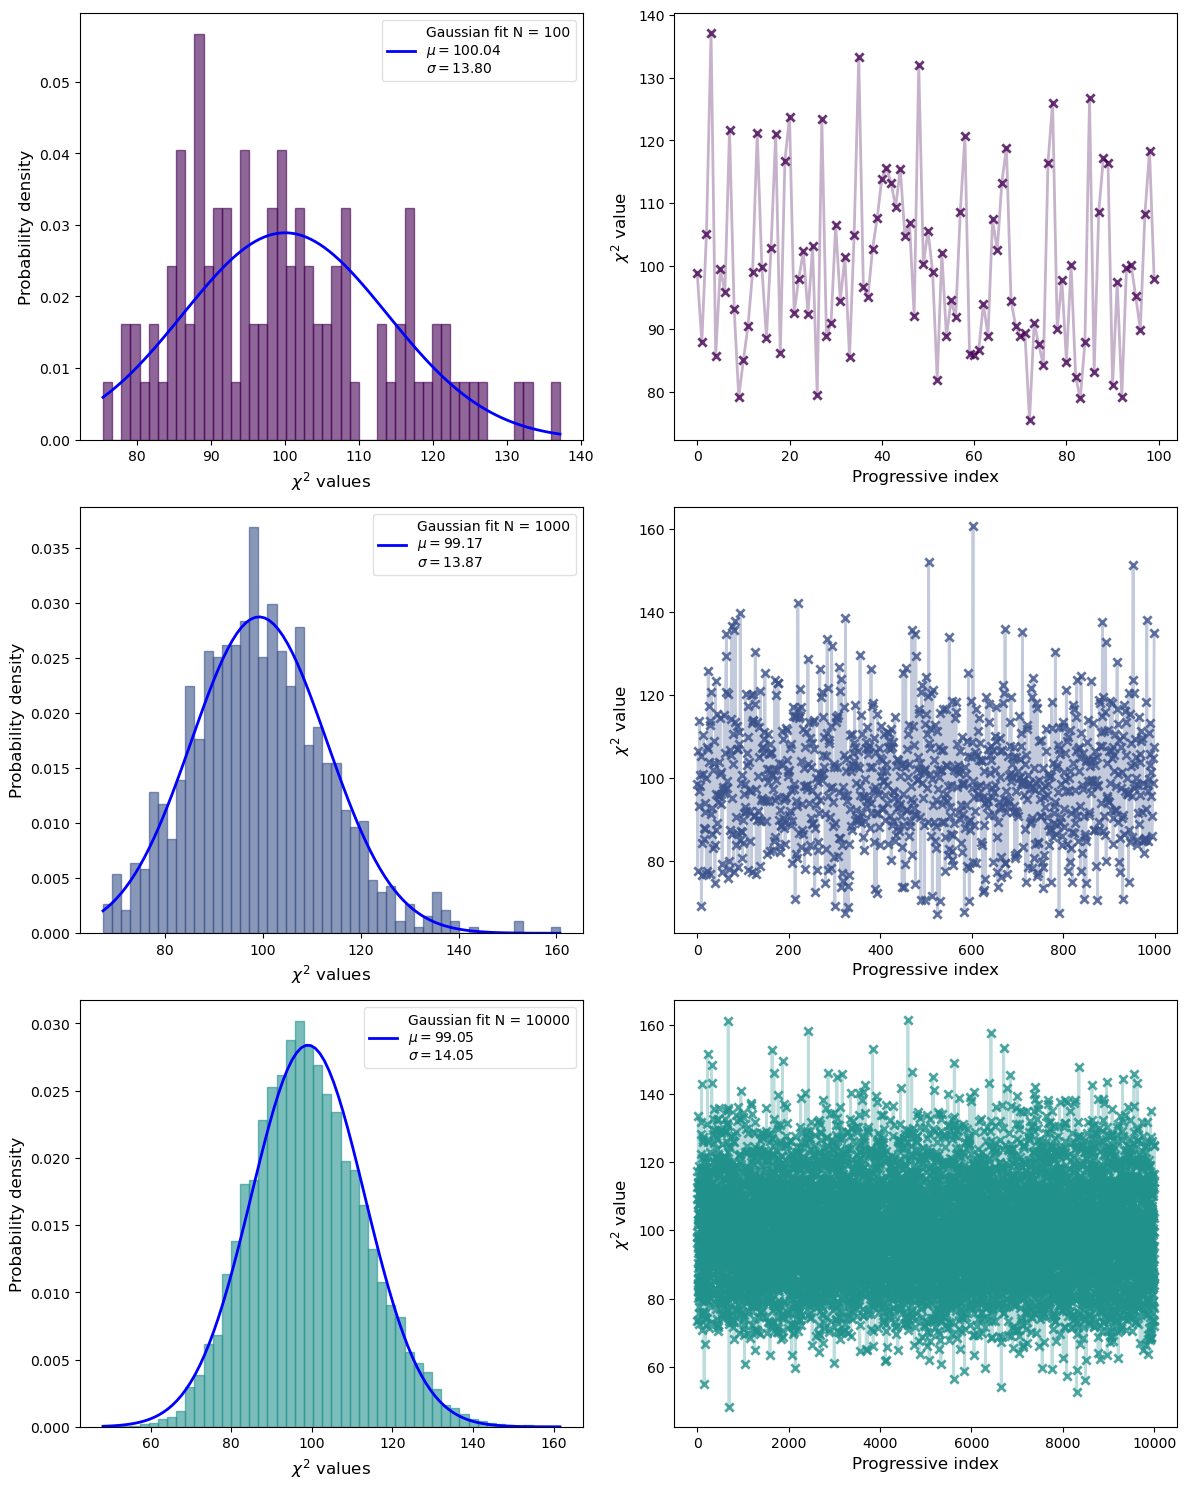

In [13]:
def read_data(file):
    with open(file, 'r') as f:
        data = [float(line.strip()) for line in f]
    return data

def plot_data(file_counts, file_chi, ax_index, title, color, bins):
    data_counts = read_data(file_counts)
    data_chi = read_data(file_chi)
    mu, sigma = norm.fit(data_chi) 

    axs[ax_index, 0].hist(
        data_chi, bins=bins, color=color, alpha=0.6, edgecolor=color, density=True
    )
    axs[ax_index, 0].set_xlabel('$\\chi^2$ values')
    axs[ax_index, 0].set_ylabel('Probability density')
    x_vals = np.linspace(np.min(data_chi), np.max(data_chi), 100)
    y_vals = norm.pdf(x_vals, mu, sigma)
    axs[ax_index, 0].plot(
        x_vals, y_vals,linestyle='-', color='b', 
        label=f'Gaussian fit {title}\n$\\mu = {mu:.2f}$\n$\\sigma = {sigma:.2f}$'
    )
    axs[ax_index, 0].legend(loc='upper right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6)

    axs[ax_index, 1].scatter(
        range(len(data_chi)), data_chi, color=color, marker='x', alpha=0.8
    )
    axs[ax_index, 1].plot(
        range(len(data_chi)), data_chi, linestyle='-', color=color, alpha=0.3
    )
    axs[ax_index, 1].set_xlabel('Progressive index')
    axs[ax_index, 1].set_ylabel('$\\chi^2$ value')


fig, axs = plt.subplots(3, 2, figsize=(12, 15))
files = [
    ('Exercise_1_1/output_counts_100.data', 'Exercise_1_1/output_chi_100.data', 'N = 100', 50),
    ('Exercise_1_1/output_counts_1000.data', 'Exercise_1_1/output_chi_1000.data', 'N = 1000', 50),
    ('Exercise_1_1/output_counts_10000.data', 'Exercise_1_1/output_chi_10000.data', 'N = 10000', 50)
]
viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(files)+2))
hex_colors = [mcolors.to_hex(c) for c in viridis_colors]

for i, (file_counts, file_chi, title, bins) in enumerate(files):
    plot_data(file_counts, file_chi, i, title, hex_colors[i], bins)

plt.tight_layout()
plt.show()


## Exercise 1.2
Extend Pseudo-Random Number generator downloaded from the NSL Ariel web site and check the Central Limit Theorem:

1. Add two probability distributions by using the **method of the inversion of the cumulative distribution** to sample from a **generic** exponential distribution

$$ p(x) = \lambda \exp(-\lambda x) \hspace{0.8cm}x\in [0;+\infty]$$

and a **generic** Cauchy-Lorentz distribution
$$
p(x)=\frac{1}{\pi}\frac{\Gamma}{(x-\mu)^2+\Gamma^2}\hspace{0.8cm}x\in [-\infty;+\infty].
$$ 

2. Make 3 pictureswith the histograms obtained filling them with $10^4$ realizations of $S_N = \frac{1}{N}\sum_{i=1}^N x_i$ (for $N=1, 2, 10, 100$), being $x_i$ a random variable sampled throwing a *standard* dice (fig.1), an *exponential* dice (fig.2, use $\lambda=1$) and a *Lorentzian* dice (fig.3, use $\mu=0$ and $\Gamma=1$).

Note tha you can try to fit the case $N=100$ with a Gaussian for standard and exponential dices, whereas you should use a Cauchy-Lorentz distribution for the last case.

## Exercise 1.2 - Solution
In this part we added two generators fro pseudorandom numbers according to a exponential and a Cauchy-Lorentz distributions. In order to implement these probability distributions the inverse cumulative method has been used. the Inverse Transform Method is to generate a random variable $x$ following a specific probability density function $p(x)$, starting from a uniform random variable $u \in [0, 1)$.


Given a cumulative distribution function $F_x(x)$ and set it equal to a uniform random variable $u$, we can find $x$ by inverting the function 
$$
F(x)=\displaystyle\int_{-\infty}^x p(x') dx' .
$$
Then we set $F(x) = u$, where $u \sim \text{Uniform}(0, 1)$ and we solve $x = F^{-1}(u)$.

#### For example - exponential distribution
The probability density functionfor a generic exponential distribution is
$$
p(x) = \lambda e^{-\lambda x}, \quad x \in [0, +\infty)
$$
We calculate the 
$$
F(x) = \int_{0}^{x} \lambda e^{-\lambda t} dt = \left[ -e^{-\lambda t} \right]_{0}^{x} = 1 - e^{-\lambda x}
$$
Then we invert the function, set $u = 1 - e^{-\lambda x}$
$$
e^{-\lambda x} = 1 - u \implies -\lambda x = \ln(1 - u) \implies x = -\frac{1}{\lambda} \ln(1 - u)
$$
Since $u$ is uniformly distributed between 0 and 1, $(1 - u)$ is also uniformly distributed. For simplicity, we can use:$$\mathbf{x = -\frac{1}{\lambda} \ln(u)} .$$


#### Verify the Central Limit Theorem
We analyze the behavior of the sample mean $S_N$ to verify the Central Limit Theorem
$$
S_N = \frac{1}{N} \sum_{i=1}^{N} x_i
$$
where $N = 1, 2, 10, 100$. For each value of $N$, we generate $M = 10^4$ realizations of $S_N$.
For the variables $x_i$ sampled from uniform and exponential distributions, the distribution of $S_N$ converges to a gaussian distribution as $N$ increases. The mean is equal to the expected value of the starting distribution. And, as well, the variance of the gaussian is equal to the variance of the starting distribution divided by $N$.

For the Cauchy-Lorentz distribution ($\mu=0, \Gamma=1$), the limit distribution is not a gaussian anymore. This happens due to the fact that the distribution does not satisfy the requirements of the standard Central Limit Theorem because it has an infinite variance. 
It is a distribution where the probability density decays according to an inverse power law
$$
p(x) \sim \frac{1}{|x|^{1+\alpha}}, \quad 0 < \alpha < 2, \quad x \to \infty .
$$

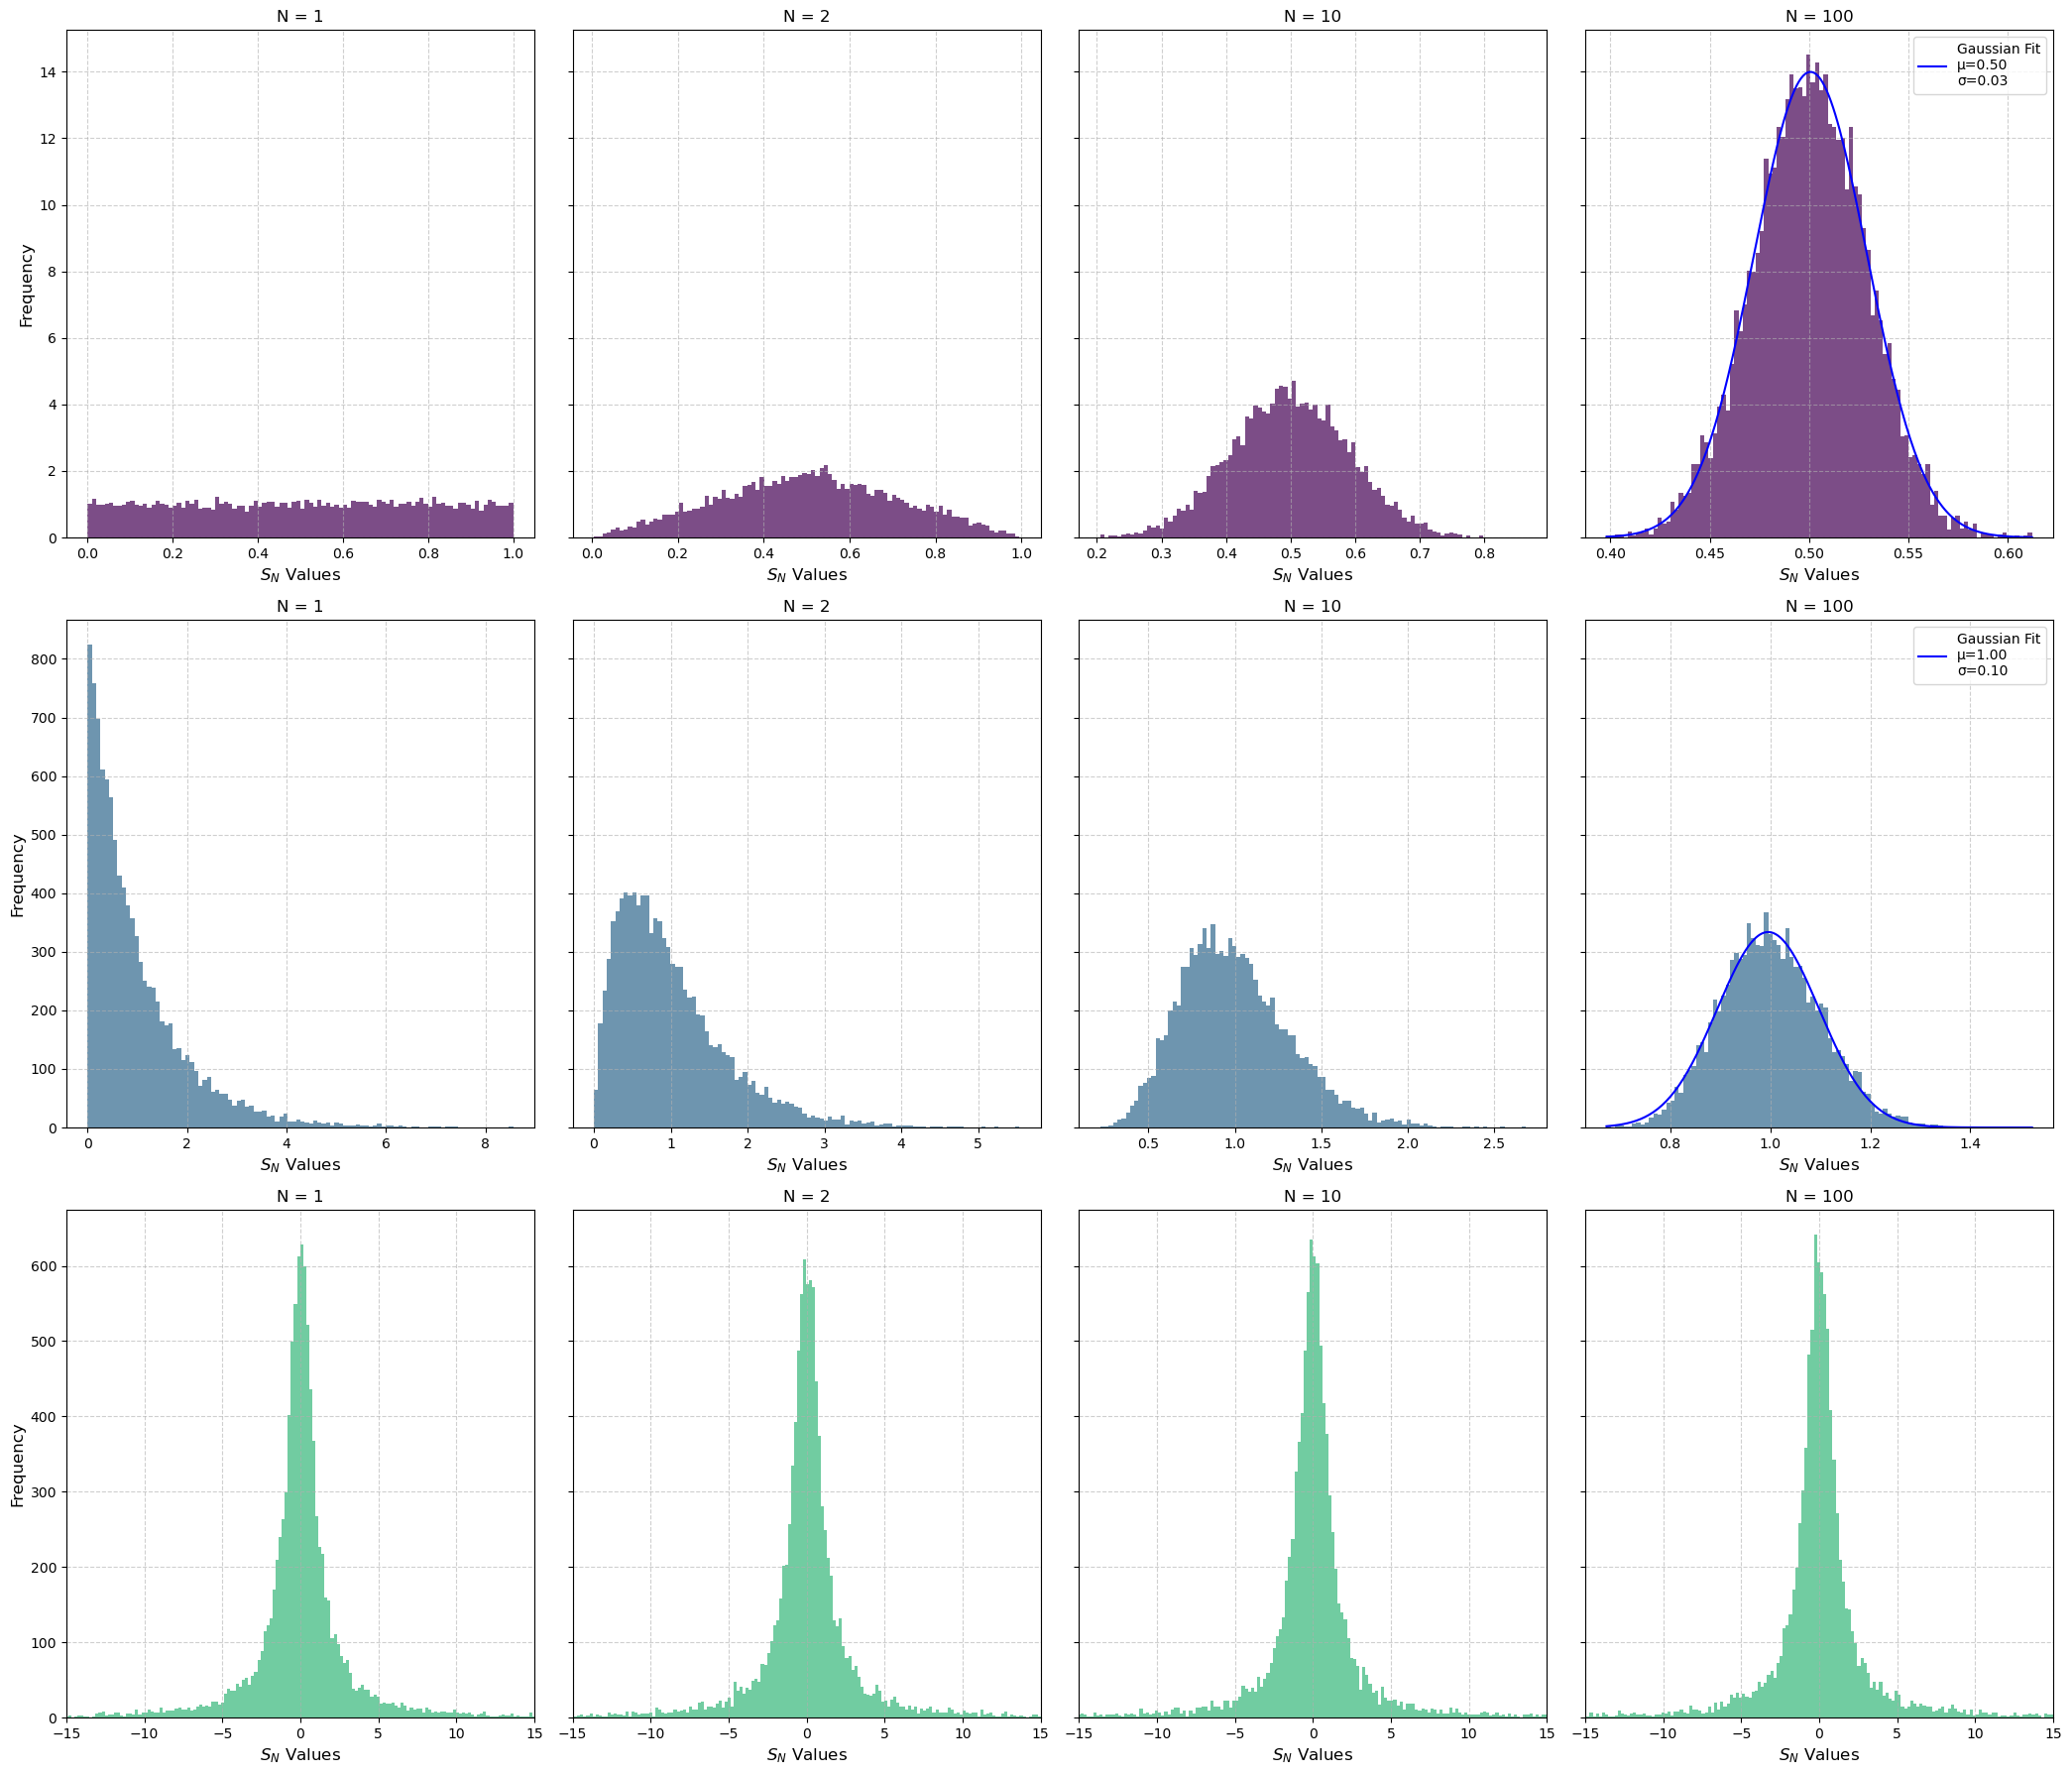

In [7]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

filenames = {
    "1": "Exercise_1_2/output_N1.txt",
    "2": "Exercise_1_2/output_N2.txt",
    "10": "Exercise_1_2/output_N10.txt",
    "100": "Exercise_1_2/output_N100.txt"
}

row_colors = plt.cm.viridis(np.linspace(0, 1, 4))
row_hex = [mcolors.to_hex(c) for c in row_colors]

fig, axs = plt.subplots(3, 4, figsize=(21, 18), sharey='row')

for idx, (N_label, filename) in enumerate(filenames.items()):
    try:
        data = np.loadtxt(filename, skiprows=1)
        hist_data, bins, _ = axs[0, idx].hist(data[:, 0], bins=100, alpha=0.7, color=row_hex[0], density=True)
        axs[0, idx].set_xlabel("$S_N$ Values")
        axs[0, 0].set_ylabel("Frequency")
        axs[0, idx].set_title(f"N = {N_label}")
        axs[0, idx].grid(True, alpha=0.6, linestyle='--')

        if N_label == "100":
            bin_centers = (bins[:-1] + bins[1:]) / 2
            popt, _ = curve_fit(gaussian, bin_centers, hist_data,
                                p0=[1, np.mean(data[:, 0]), np.std(data[:, 0])])
            x = np.linspace(min(data[:, 0]), max(data[:, 0]), 200)
            axs[0, idx].plot(x, gaussian(x, *popt), color='b', lw=1.5,
                             label=f'Gaussian Fit\nμ={popt[1]:.2f}\nσ={popt[2]:.2f}')
            axs[0, idx].legend()

        hist_data, bins, _ = axs[1, idx].hist(data[:, 1], bins=100, alpha=0.7, color=row_hex[1])
        axs[1, idx].set_xlabel("$S_N$ Values")
        axs[1, 0].set_ylabel("Frequency")
        axs[1, idx].set_title(f"N = {N_label}")
        axs[1, idx].grid(True, alpha=0.6, linestyle='--')

        if N_label == "100":
            bin_centers = (bins[:-1] + bins[1:]) / 2
            popt, _ = curve_fit(gaussian, bin_centers, hist_data,
                                p0=[1, np.mean(data[:, 1]), np.std(data[:, 1])])
            x = np.linspace(min(data[:, 1]), max(data[:, 1]), 200)
            axs[1, idx].plot(x, gaussian(x, *popt), color='b', lw=1.5,
                             label=f'Gaussian Fit\nμ={popt[1]:.2f}\nσ={popt[2]:.2f}')
            axs[1, idx].legend()

        filtered_data = data[:, 2][(data[:, 2] >= -50) & (data[:, 2] <= 50)]
        axs[2, idx].hist(filtered_data, bins=500, alpha=0.7, color=row_hex[2])
        axs[2, idx].set_xlabel("$S_N$ Values")
        axs[2, 0].set_ylabel("Frequency")
        axs[2, idx].set_xlim(-15., 15.)
        axs[2, idx].set_title(f"N = {N_label}")
        axs[2, idx].grid(True, alpha=0.6, linestyle='--')

    except Exception as e:
        print(f"Error processing {filename}: {e}")

plt.tight_layout()
plt.show()


## Exercise 1.3
Simulate the Buffon’s experiment (see LSN_Lecture_00, supplementary material):  A needle of length $L$ is thrown at random onto a horizontal plane ruled with straight lines a distance $d$ (must be $d > L$, but do not use $d\gg L$ otherwise $P\ll 1$) apart. The probability $P$ that the needle will intersect one of these lines is: $P = 2L/\pi d$. This could be used to evaluate $\pi$ from throws of the needle: if the needle is thrown down $N_{thr}$ times and is observed to land on a line $N_{hit}$ of those times, we can make an estimate of $\pi$ from
$$\pi = \frac{2L}{Pd} = \lim_{N_{thr} \to \infty}\frac{2LN_{thr}}{N_{hit}d}$$
Make a picture of the estimation of $\pi$ and its uncertainty (Standard Deviation of the mean) with a large number of *throws* $M$ as a function of the number of blocks, $N$(see below: Computing statistical uncertainties). If possible, do not use $\pi$ to evaluate $\pi$.


## Exercise 1.3 - Solution
We initialized the experiment with a needle length $l = 0.8$ and a grid spacing $d = 1.0$, ensuring the condition $d > l$. The total number of throws $M = 10^4$ is divided into $N = 100$ blocks, meaning each block contains $L = 100$ throws. 
In the simulation for every throw, the code generates a random vertical position for the needle's center, $y_{center}$, uniformly distributed between 0 and $d$. It also generates a random orientation $\alpha$. To determine if a hit event occurs, the code calculates the vertical coordinates of the needle's endings
$$
y_{sup} = y_{center} + \frac{l}{2} \sin(\alpha)
$$
$$
y_{inf} = y_{center} - \frac{l}{2} \sin(\alpha)
$$
if $y_{sup} > d$ or $y_{inf} < 0$, the needle has crossed one of the parallel lines. 
In these cases, the counter $N_\text{hit}$ is incremented.

To calculate $\pi$ we computed an estimation of $\pi$ using the formula 
$$
\pi \approx \frac{2l \cdot L}{N_\text{hit} \cdot d} \ ,
$$
these are the instantaneous values which are used in the data blocking process.

To satisfy the constraint of not using $\pi$ to calculate $\pi$, the Angle() function employs a rejection technique. The code generates random points $(x, y)$ within a square of side 2 centered at the origin. Points that fall outside the unit circle ($x^2 + y^2 \ge 1$) are rejected. For the accepted points, the code calculates the angle $\alpha$ using the relation
$$
\alpha = \text{arccos}\left(\frac{x}{\sqrt{x^2 + y^2}}\right)
$$

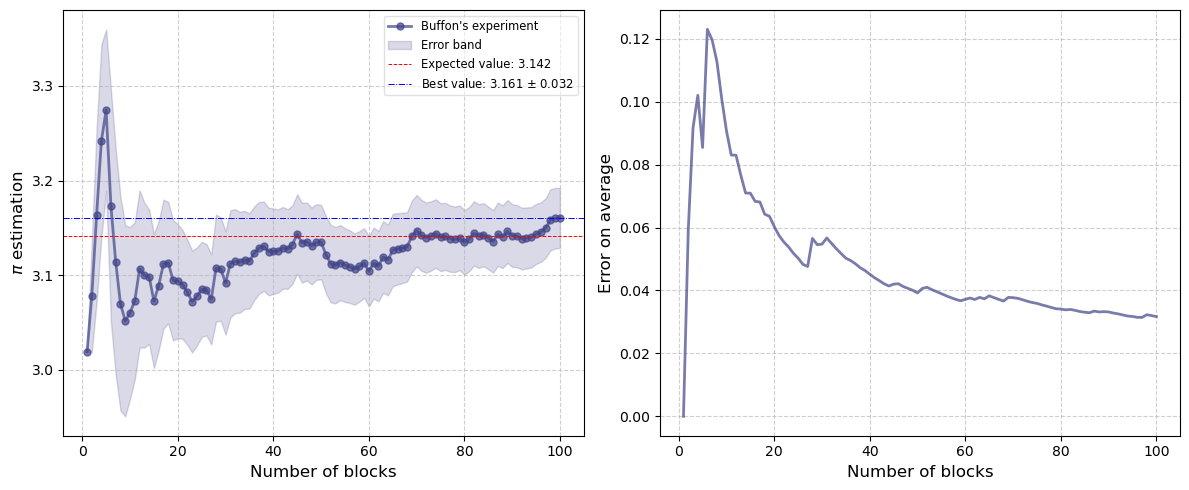

In [4]:
file1 = "Exercise_1_3/output_average.data"
x1, y1, error1 = np.loadtxt(file1, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x2, y2 = np.loadtxt(file1, usecols=(0, 2), delimiter='\t', unpack=True)

# Viridis color
viridis = plt.cm.viridis
color_std = viridis(0.2)  
color_err = viridis(0.2)
ref_color = viridis(0.1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(x1/100, y1, 'o-', color=color_std, markersize=5, alpha=0.7, label="Buffon's experiment")

axes[0].fill_between(x1/100, y1 - error1, y1 + error1,
                     color=color_std, alpha=0.2, label='Error band')

axes[0].axhline(y=np.pi, color='red', linestyle='--', linewidth=0.7,
                label=rf'Expected value: {np.pi:.3f}')

axes[0].axhline(y=y1[99], color='blue', linestyle='-.', linewidth=0.7,
                label=rf'Best value: {y1[99]:.3f} $\pm$ {error1[99]:.3f}')

axes[0].set_xlabel('Number of blocks')
axes[0].set_ylabel(r'$\pi$ estimation')
axes[0].legend(loc='upper right', frameon=True, fancybox=True,
               facecolor='white', framealpha=0.6, fontsize='small')
axes[0].grid(True, alpha=0.6, linestyle='--')

axes[1].plot(x2/100, y2, '-', color=color_err, alpha=0.7, label='Error')
axes[1].set_xlabel('Number of blocks')
axes[1].set_ylabel('Error on average')
axes[1].grid(True, alpha=0.6, linestyle='--')

plt.tight_layout()
plt.show()


### Computing statistical uncertainties: the blocking method
- A fundamental step in every Monte Carlo calculation is the estimation of its statistical uncertainty, **it's a must!** Your task would not be completed if you had not calculated it.

    In computing the statistical uncertainties, i.e. the standard deviation of the mean, you need an estimation of the variance $\sigma^2$, the second central moment. First of all note that the variance can be computed from
    $$\sigma^2_A := \langle (A-\langle A\rangle)^2\rangle = \langle A^2 \rangle -\langle A\rangle^2 $$
    What is the best way to estimate $\sigma^2_A$? Imagine that your Monte Carlo estimation of $A$ is obtained from a calculation which uses $M$ Monte Carlo "steps" (intentionally, here I am generic because what is a single "step" in a Monte Carlo calculation strictly depends on the specific calculation); you can always divide such $M$ Monte Carlo "steps" in $N$ blocks, with $N<M$. In each block, you can use your $M/N$ Monte Carlo "steps" to obtain an estimate of $A$, let me call it $A_i$ with $i=1,N$, and then you have also $A^2_i$ with $i=1,N$.
    At this point everything becomes clear:
    $$ \langle A^2 \rangle \simeq \frac{1}{N} \sum_{i=1}^N A^2_i \quad \quad \langle A\rangle^2 \simeq \left( \frac{1}{N} \sum_{i=1}^N A_i \right)^2 $$
    and finally the statistical uncertainty with $N$ :
    $$\frac{\sigma}{\sqrt{N-1}} \simeq \sqrt{\frac{1}{N-1} \left[ \frac{1}{N} \sum_{i=1}^N A^2_i - \left( \frac{1}{N} \sum_{i=1}^N A_i \right)^2 \right]} $$

-   In a Monte Carlo calculation, you can use the arguments above to outputting an estimate of A and its statistical uncertainty on the fly, during your calculation. You will be able to do this every $M/N$ steps, and thus, in the end, $N$ times. Note that after the first $M/N$ Monte Carlo steps, at the end of the first block, your estimation of the uncertainty is not computable, so set it to zero and compute it only from the second block. **Question**: $N$ can be chosen in many ways ... what are the limitations regarding this choice?